# Finding Affordable Housing in NYC

## Why is it so hard?


#### Affordable housing is one of the biggest challenges facing New York City today. We love living in New York City, but we have to admit that finding good, affordable housing can feel like searching for a needle in a haystack. Although the City of New York continues to invest in building affordable housing, many residents still struggle to find a home they can afford. Using two datasets from NYC Open Data—**Affordable Housing Production by Building**, **Advertised Housing Lotteries by Building** and **Local Law 44 Unit Income Rent**—we explored where affordable housing is being built, how it compares to available housing lotteries, and why finding affordable housing remains so difficult for many New Yorkers.


In [ ]:
import pandas as pd
import seaborn as sns
import plotly.express as px 
import matplotlib.pyplot as plt
import numpy as np

al = pd.read_csv("Advertised_Lotteries_on_Housing_Connect_By_Building_20260715.csv")
ah = pd.read_csv("Affordable_Housing_Production_by_Building_20260715.csv")
ll44 = pd.read_csv("Local_Law_44_-_Unit_Income_Rent_20260720.csv")

### Here we just did some basic data wrangling for our column names. Some names had an extra space while most names were too long. 

In [44]:
al = al.rename(columns={
    "Applied Income AMI Category - Extremely Low Income": "Extremely Low Income",
    "Applied Income AMI Category - Very Low Income":"Very Low Income",
    "Applied Income AMI Category - Low Income ": "Low Income",
    "Applied Income AMI Category - Moderate Income": "Moderate Income",
    "Applied Income AMI Category - Middle Income": "Middle Income",
    "Applied Income AMI Category - Above Middle Income": "Above Middle Income"
})

In [46]:
#Cleaning missing values
ah.isna().sum()
ah = ah.dropna(subset=["Extremely Low Income Units"])

# So where is the "affordable housing" being built? 

In [48]:
#Affordable housing production by building
ah["Borough"].value_counts()

Borough
Brooklyn         643
Bronx            586
Manhattan        513
Queens           168
Staten Island     73
Name: count, dtype: int64

In [49]:
# Count affordable housing production by borough
production = ah["Borough"].value_counts().sort_index()

# Count Housing Connect lottery buildings by borough
lottery = al["Borough"].value_counts().sort_index()

# Combine into one DataFrame
comparison = pd.DataFrame({
    "Housing Production": production,
    "Lottery Buildings": lottery
}).fillna(0)

# Convert counts to percentages
comparison["Housing Production (%)"] = (
    comparison["Housing Production"] /
    comparison["Housing Production"].sum()
) * 100

comparison["Lottery Buildings (%)"] = (
    comparison["Lottery Buildings"] /
    comparison["Lottery Buildings"].sum()
) * 100

comparison

,Housing Production,Lottery Buildings,Housing Production (%),Lottery Buildings (%)
Borough,,,,
Bronx,586,520,29.551185,24.975985
Brooklyn,643,921,32.425618,44.236311
Manhattan,513,244,25.869894,11.719500
Queens,168,381,8.472012,18.299712
Staten Island,73,16,3.681291,0.768492


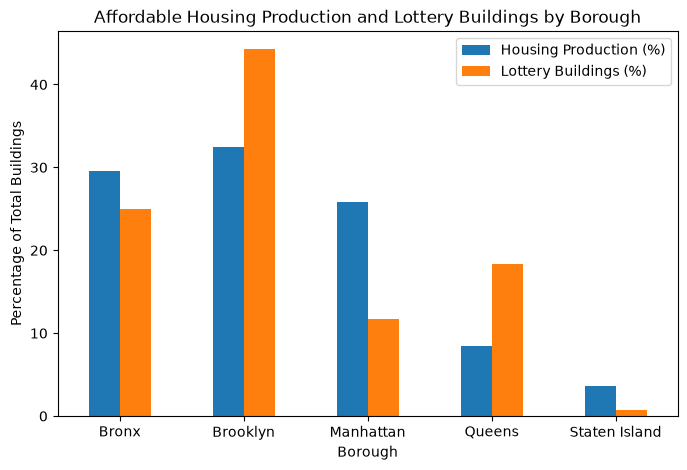

In [50]:
comparison[[
    "Housing Production (%)",
    "Lottery Buildings (%)"
]].plot(kind="bar", figsize=(8,5))

plt.title("Affordable Housing Production and Lottery Buildings by Borough")
plt.ylabel("Percentage of Total Buildings")
plt.xlabel("Borough")
plt.xticks(rotation=0)
plt.show()

In [51]:
#Which borough has the most affordable housing?
ah["Total Units"] = pd.to_numeric(
    ah["Total Units"],
    errors="coerce"
)

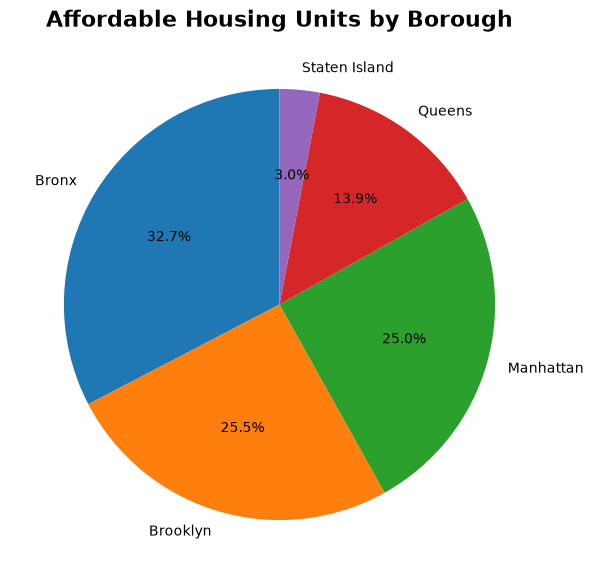

In [12]:
plt.figure(figsize=(7,7))

plt.pie(
    borough_units,
    labels=borough_units.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Affordable Housing Units by Borough",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [54]:
borough_units = ah.groupby("Borough")["Total Units"].sum()

### So we can see where affordable housing is being built and our next question was ok well how many of those units is actually for people with lower income? 

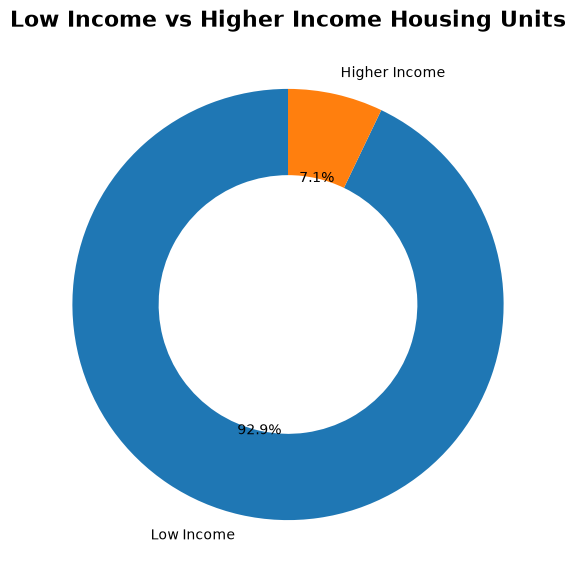

In [17]:
plt.figure(figsize=(7,7))

plt.pie(
    income_compare["Units"],
    labels=income_compare["Income Group"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title(
    "Low Income vs Higher Income Housing Units",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [16]:
#High Income Units vs Low Income Units Available
income_compare = pd.DataFrame({
    "Income Group": ["Low Income", "Higher Income"],
    "Units": [
        ah[["Extremely Low Income Units",
            "Very Low Income Units",
            "Low Income Units"]].sum().sum(),

        ah[["Moderate Income Units",
            "Middle Income Units",
            "Other Income Units"]].sum().sum()
    ]
})

income_compare

,Income Group,Units
0,Low Income,124072.0
1,Higher Income,9510.0


Text(0.5, 1.0, 'Affordable Housing Units by Income Category')

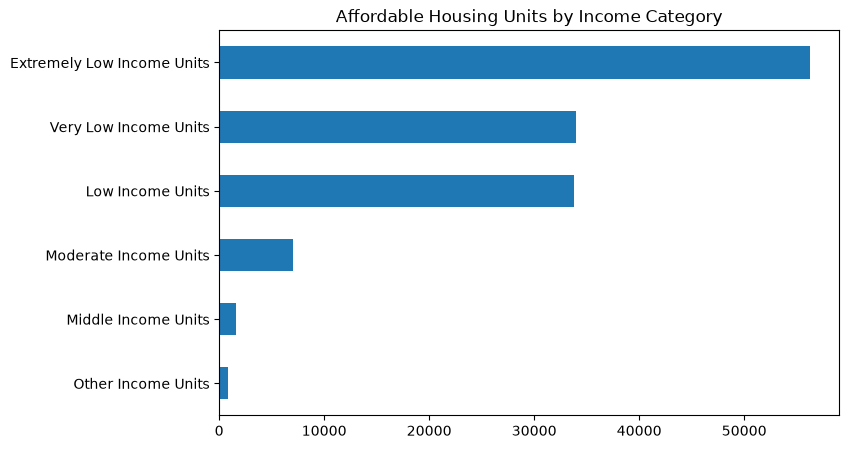

In [55]:
income_totals = ah [[
    "Extremely Low Income Units",
    "Very Low Income Units",
    "Low Income Units",
    "Moderate Income Units",
    "Middle Income Units",
    "Other Income Units",
]].sum()

income_totals.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Affordable Housing Units by Income Category")

# What types of units are being built and how much do they cost?

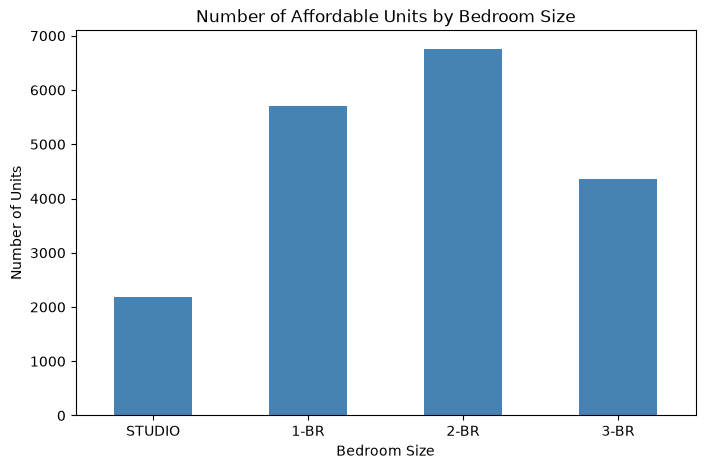

In [43]:
#What are the units being built and how much do they cost 
type_of_bedroom = subset["BedroomSize"].value_counts().reindex(
    ["STUDIO", "1-BR", "2-BR", "3-BR"]
)

type_of_bedroom.plot(
    kind="bar",
    figsize=(8,5),
    color="steelblue"
)

plt.title("Number of Affordable Units by Bedroom Size")
plt.xlabel("Bedroom Size")
plt.ylabel("Number of Units")
plt.xticks(rotation=0)

plt.show()

# Who qualifies for these apartments? 

### If these units exists, who is actually able to rent them? 
#### AMI or Area Median Income is used to determine eligibility. Different apartments are reserved for households earning different percentages of the area's median income. People who apply must fall within specific income ranges to qualify.

In [67]:
#In our dataset we had a lot of 0s and alot of NaNs which made it difficult to really prove about rent and how much you would 
#Actually pay should you get past all other obstacles
clean_ll44 = ll44[
    (ll44["MaxAllowableIncome"].notna()) &
    (ll44["MedianInitialLegalRent"].notna()) &
    (ll44["MedianActualRent"].notna()) &
    (ll44["MaxAllowableIncome"] != 0) &
    (ll44["MedianInitialLegalRent"] != 0) &
    (ll44["MedianActualRent"] != 0)
]

clean_ll44.head()

,ProjectID,BuildingID,BedroomSize,MaxAllowableIncome,TotalUnits,MedianInitialLegalRent,HighInitialLegalRent,LowInitialLegalRent,MedianActualRent,HighActualRent,LowActualRent
0,50206,287193.0,2-BR,0%-30%,1,"1,554","1,554","1,554",0,0,0
1,50206,383480.0,STUDIO,0%-30%,1,"1,531","1,531","1,531",0,0,0
2,50206,383478.0,2-BR,0%-30%,1,"1,554","1,554","1,554",0,0,0
9,58589,332727.0,1-BR,0%-30%,1,"1,411","1,411","1,411",906,906,906
10,58589,317083.0,1-BR,0%-30%,2,"1,659.5","2,386",933,"1,659.5","2,386",933


In [68]:
#I wanted to show that we had 20,033 rows but only 5,493 rows are usable in our analysis
print("Original rows:", len(ll44))
print("Usable rows:", len(clean_ll44))

Original rows: 20033
Usable rows: 5493


In [59]:
#Here we tried to analyze and show to you our audience the income requirements and
#rent ranges in the Local Law 44 dataset to determine if these aparements were truely afforable
#However we found the majority of values were either missing or the wrong type. 
#Rather than filling in or estimating we wanted to present the dataset that exists 

ll44[[
    "MaxAllowableIncome",
    "MedianInitialLegalRent",
    "MedianActualRent"
]].dtypes

MaxAllowableIncome        str
MedianInitialLegalRent    str
MedianActualRent          str
dtype: object

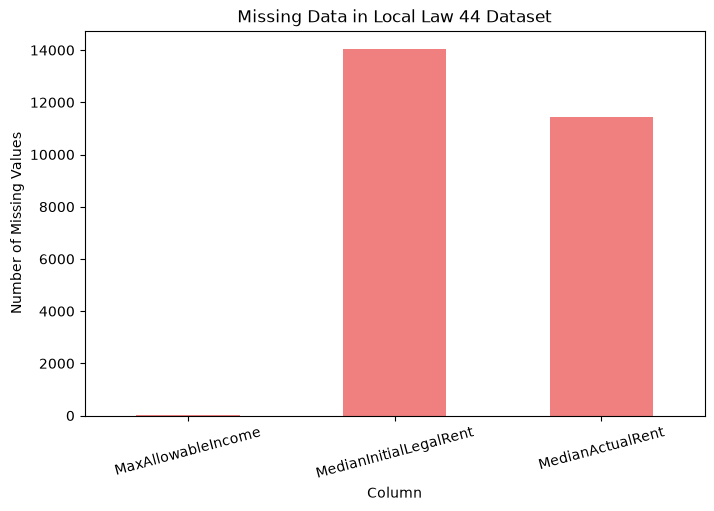

In [65]:
missing_data = ll44[[
    "MaxAllowableIncome",
    "MedianInitialLegalRent",
    "MedianActualRent"
]].isna().sum()

missing_data.plot(
    kind="bar",
    figsize=(8,5),
    color="lightcoral"
)

plt.title("Missing Data in Local Law 44 Dataset")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=15)
plt.show()

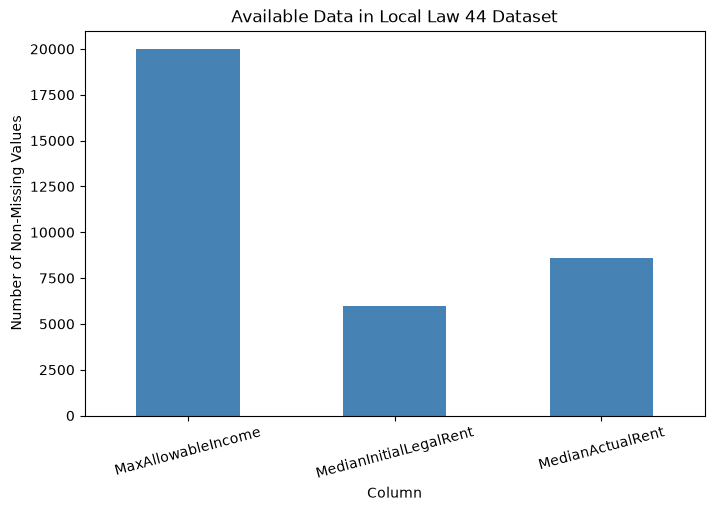

In [66]:
available_data = ll44[[
    "MaxAllowableIncome",
    "MedianInitialLegalRent",
    "MedianActualRent"
]].count()

available_data.plot(
    kind="bar",
    figsize=(8,5),
    color="steelblue"
)

plt.title("Available Data in Local Law 44 Dataset")
plt.xlabel("Column")
plt.ylabel("Number of Non-Missing Values")
plt.xticks(rotation=15)
plt.show()

### Conclusion

#### We chose this topic because our frustrations with finding affordable housing are likely the same frustrations many New Yorkers experience. Through our analysis, we found that affordable housing is being built, but it is concentrated in certain areas of the city. We also examined the types of apartments being offered, the number of available units, and the income requirements needed to qualify. While affordable housing does exist, its limited supply and strict eligibility requirements make it difficult for many New Yorkers to secure a home. Our findings suggest that the challenge is not simply the lack of affordable housing, but also ensuring that enough housing is available and accessible to the people who need it most.
